# 修改版网格世界 — 值迭代与探索动画

**环境修改：**
- S12（禁止区域）：进入奖励 **-5**
- S7（特殊状态）：进入奖励 **-2**
- S8（宝藏）：进入奖励 **0**
- 其余状态：进入奖励 **-1**
- 多最优动作时：**等概率**选择

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import FancyArrowPatch, Patch
from matplotlib.animation import FuncAnimation
from IPython.display import HTML
import sys, os

plt.rcParams['font.sans-serif'] = ['SimHei']
plt.rcParams['axes.unicode_minus'] = False

# 导入修改版环境（兼容不同工作目录）
try:
    from MDP.modified_env import (ModifiedGridworldEnv, TREASURE_LOCATION,
                                    FORBIDDEN_LOCATION, SPECIAL_LOCATION)
except ImportError:
    from modified_env import (ModifiedGridworldEnv, TREASURE_LOCATION,
                              FORBIDDEN_LOCATION, SPECIAL_LOCATION)

env = ModifiedGridworldEnv()
print(f'环境创建完成: {env.nS}个状态, {env.nA}个动作')
print(f'宝藏位置: S{TREASURE_LOCATION}, 禁止区域: S{FORBIDDEN_LOCATION}, 特殊状态: S{SPECIAL_LOCATION}')
print(f'网格形状: {env.shape}')

环境创建完成: 25个状态, 4个动作
宝藏位置: S8, 禁止区域: S12, 特殊状态: S7
网格形状: [5, 5]


In [2]:
# ============================================================
# 值迭代 + 等概率策略
# ============================================================

def value_iteration_equal_prob(env, threshold=0.0001, discount_factor=1.0):
    def one_step_lookahead(state, V):
        q = np.zeros(env.nA)
        for a in range(env.nA):
            for prob, next_state, reward, done in env.P[state][a]:
                q[a] += prob * (reward + discount_factor * V[next_state])
        return q

    V = np.zeros(env.nS)
    V_current = np.zeros(env.nS)
    delta_history = []
    V_history = []
    i_num = 0

    while True:
        delta = 0
        for s in range(env.nS):
            q = one_step_lookahead(s, V_current)
            best_action_value = np.max(q)
            delta = max(delta, np.abs(best_action_value - V_current[s]))
            V[s] = best_action_value

        i_num += 1
        V_current = np.copy(V)
        delta_history.append(delta)
        V_history.append(V_current.copy())

        if delta < threshold:
            print(f'值迭代收敛于 {i_num} 次迭代, 最终 delta = {delta:.6f}')
            break

    # 等概率策略：多最优动作均分概率
    policy = np.zeros([env.nS, env.nA])
    for s in range(env.nS):
        q = one_step_lookahead(s, V)
        max_q = np.max(q)
        best_actions = np.where(np.abs(q - max_q) < 1e-10)[0]
        prob = 1.0 / len(best_actions)
        for a in best_actions:
            policy[s][a] = prob

    return policy, V, delta_history, V_history


policy, v, delta_history, V_history = value_iteration_equal_prob(env)
value_grid = v.reshape(env.shape)

action_names = ['up', 'right', 'down', 'left']
print('\n最优值函数 (5x5 grid):')
print(np.round(value_grid, 2))
print('\n各状态策略概率分布:')
for s in range(env.nS):
    if np.any(policy[s] > 0):
        acts = ', '.join([f'{action_names[a]}={policy[s][a]:.2f}'
                          for a in range(env.nA) if policy[s][a] > 0])
        pos = np.unravel_index(s, env.shape)
        print(f'  S{s} ({pos[0]},{pos[1]}): {acts}')

值迭代收敛于 6 次迭代, 最终 delta = 0.000000

最优值函数 (5x5 grid):
[[-3. -2. -1.  0. -1.]
 [-3. -2.  0.  0.  0.]
 [-4. -3. -1.  0. -1.]
 [-4. -3. -2. -1. -2.]
 [-5. -4. -3. -2. -3.]]

各状态策略概率分布:
  S0 (0,0): right=1.00
  S1 (0,1): right=1.00
  S2 (0,2): right=1.00
  S3 (0,3): down=1.00
  S4 (0,4): down=0.50, left=0.50
  S5 (1,0): right=1.00
  S6 (1,1): right=1.00
  S7 (1,2): right=1.00
  S8 (1,3): up=0.25, right=0.25, down=0.25, left=0.25
  S9 (1,4): left=1.00
  S10 (2,0): up=0.50, right=0.50
  S11 (2,1): up=1.00
  S12 (2,2): right=1.00
  S13 (2,3): up=1.00
  S14 (2,4): up=0.50, left=0.50
  S15 (3,0): right=1.00
  S16 (3,1): right=1.00
  S17 (3,2): right=1.00
  S18 (3,3): up=1.00
  S19 (3,4): up=0.50, left=0.50
  S20 (4,0): up=0.50, right=0.50
  S21 (4,1): up=0.50, right=0.50
  S22 (4,2): up=0.50, right=0.50
  S23 (4,3): up=1.00
  S24 (4,4): up=0.50, left=0.50


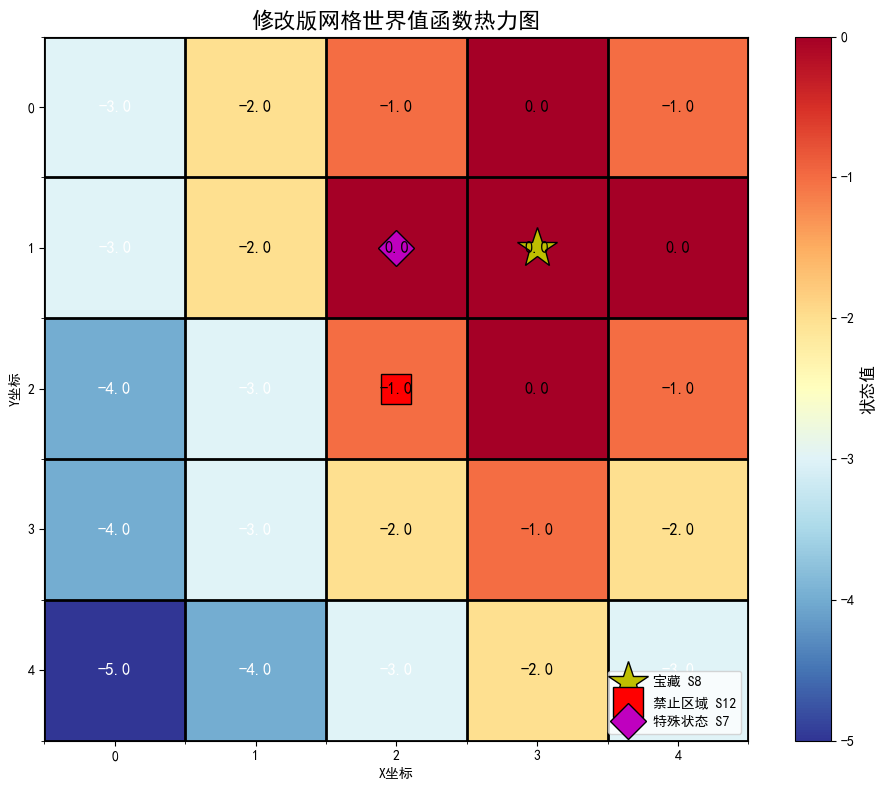

In [3]:
# ============================================================
# 1. 值函数热力图
# ============================================================
fig, ax = plt.subplots(figsize=(10, 8))
treasure_pos = np.unravel_index(TREASURE_LOCATION, env.shape)
forbidden_pos = np.unravel_index(FORBIDDEN_LOCATION, env.shape)
special_pos = np.unravel_index(SPECIAL_LOCATION, env.shape)

heatmap = ax.imshow(value_grid, cmap='RdYlBu_r')

for i in range(value_grid.shape[0]):
    for j in range(value_grid.shape[1]):
        val = value_grid[i, j]
        color = 'black' if abs(val) < 2.5 else 'white'
        ax.text(j, i, f'{val:.1f}', ha='center', va='center',
                color=color, fontsize=12, fontweight='bold')

ax.plot(treasure_pos[1], treasure_pos[0], 'y*', markersize=30,
        markeredgecolor='black', label='宝藏 S8')
ax.plot(forbidden_pos[1], forbidden_pos[0], 'rs', markersize=22,
        markeredgecolor='black', label='禁止区域 S12')
ax.plot(special_pos[1], special_pos[0], 'mD', markersize=18,
        markeredgecolor='black', label='特殊状态 S7')

ax.set_title('修改版网格世界值函数热力图', fontsize=16, fontweight='bold')
ax.set_xlabel('X坐标'); ax.set_ylabel('Y坐标')
ax.set_xticks(np.arange(-0.5, value_grid.shape[1], 1), minor=True)
ax.set_yticks(np.arange(-0.5, value_grid.shape[0], 1), minor=True)
ax.grid(which='minor', color='black', linestyle='-', linewidth=2)
cbar = plt.colorbar(heatmap, ax=ax)
cbar.set_label('状态值', fontsize=12)
ax.legend(loc='lower right')
plt.tight_layout()
plt.show()

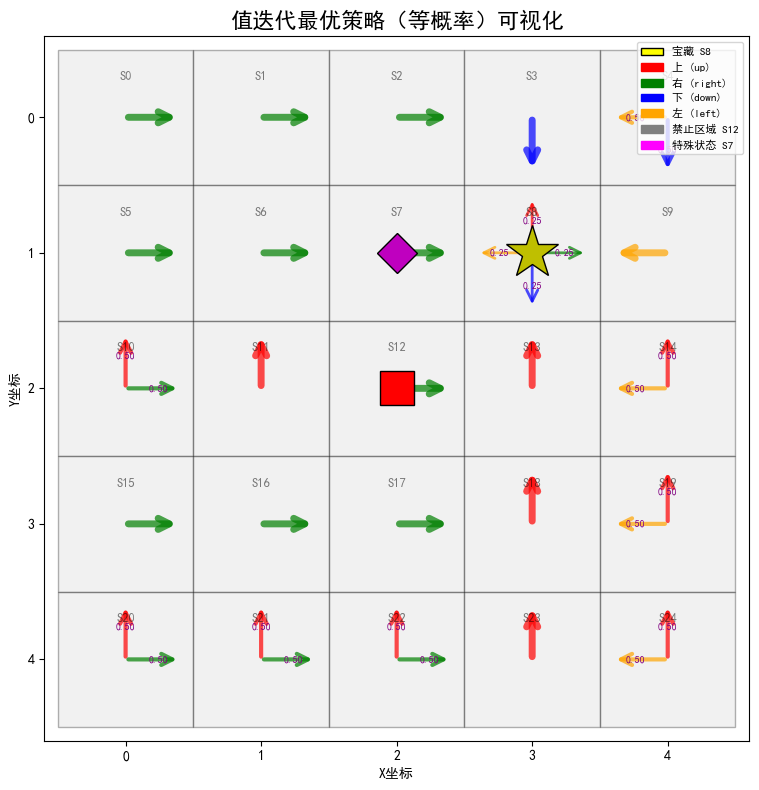

In [4]:
# ============================================================
# 2. 策略箭头图（箭头粗细反映概率大小）
# ============================================================
action_to_direction = {0: (0, -0.4), 1: (0.4, 0), 2: (0, 0.4), 3: (-0.4, 0)}
action_colors = {0: 'red', 1: 'green', 2: 'blue', 3: 'orange'}

fig, ax = plt.subplots(figsize=(10, 8))

for i in range(value_grid.shape[0]):
    for j in range(value_grid.shape[1]):
        s = i * value_grid.shape[1] + j
        rect = plt.Rectangle((j - 0.5, i - 0.5), 1, 1,
                             fill=True, edgecolor='black',
                             facecolor='lightgray', alpha=0.3)
        ax.add_patch(rect)
        ax.text(j, i - 0.3, f'S{s}', ha='center', va='center',
                fontsize=9, alpha=0.5)

        for a in range(env.nA):
            prob = policy[s][a]
            if prob > 0:
                dx, dy = action_to_direction[a]
                lw = 1 + 4 * prob  # 概率越大箭头越粗
                arrow = FancyArrowPatch((j, i), (j + dx, i + dy),
                                        arrowstyle='->', color=action_colors[a],
                                        mutation_scale=20, linewidth=lw, alpha=0.7)
                ax.add_patch(arrow)
                if 0 < prob < 1.0:
                    ax.text(j + dx * 0.6, i + dy * 0.6, f'{prob:.2f}',
                            ha='center', va='center', fontsize=7, color='purple')

ax.plot(treasure_pos[1], treasure_pos[0], 'y*', markersize=40,
        markeredgecolor='black', label='宝藏 S8', zorder=10)
ax.plot(forbidden_pos[1], forbidden_pos[0], 'rs', markersize=25,
        markeredgecolor='black', label='禁止区域 S12', zorder=10)
ax.plot(special_pos[1], special_pos[0], 'mD', markersize=20,
        markeredgecolor='black', label='特殊状态 S7', zorder=10)

legend_elements = [
    Patch(facecolor='yellow', edgecolor='black', label='宝藏 S8'),
    Patch(facecolor='red', edgecolor='red', label='上 (up)'),
    Patch(facecolor='green', edgecolor='green', label='右 (right)'),
    Patch(facecolor='blue', edgecolor='blue', label='下 (down)'),
    Patch(facecolor='orange', edgecolor='orange', label='左 (left)'),
    Patch(facecolor='gray', edgecolor='gray', label='禁止区域 S12'),
    Patch(facecolor='magenta', edgecolor='magenta', label='特殊状态 S7'),
]

ax.set_xlim(-0.6, value_grid.shape[1] - 0.4)
ax.set_ylim(-0.6, value_grid.shape[0] - 0.4)
ax.set_aspect('equal')
ax.set_title('值迭代最优策略（等概率）可视化', fontsize=16, fontweight='bold')
ax.set_xlabel('X坐标'); ax.set_ylabel('Y坐标')
ax.invert_yaxis()
ax.legend(handles=legend_elements, loc='upper right', fontsize=8)
plt.tight_layout()
plt.show()

In [5]:
# ============================================================
# 3. 从状态20出发的探索模拟
# ============================================================

def simulate_episode(env, policy, start_state, treasure_state,
                     max_steps=100, seed=None):
    if seed is not None:
        np.random.seed(seed)
    states = [start_state]
    actions = []
    rewards = []
    current = start_state
    step = 0

    while current != treasure_state and step < max_steps:
        probs = policy[current]
        action = np.random.choice(env.nA, p=probs)
        for prob, ns, r, done in env.P[current][action]:
            next_state, reward = ns, r
        states.append(next_state)
        actions.append(action)
        rewards.append(reward)
        current = next_state
        step += 1

    return states, actions, rewards

print('从 S20 出发的 5 条示例轨迹（展示等概率策略的随机性）:')
for ep in range(5):
    states, actions, rewards = simulate_episode(
        env, policy, 20, TREASURE_LOCATION, seed=ep)
    action_seq = ' -> '.join([action_names[a] for a in actions])
    total_r = sum(rewards)
    print(f'  #{ep+1} (seed={ep}): S20 -> ' +
          ' -> '.join([f'S{s}' for s in states[1:]]))
    print(f'       动作: {action_seq}, 步数: {len(states)-1}, 总奖励: {total_r}')

从 S20 出发的 5 条示例轨迹（展示等概率策略的随机性）:
  #1 (seed=0): S20 -> S21 -> S22 -> S23 -> S18 -> S13 -> S8
       动作: right -> right -> right -> up -> up -> up, 步数: 6, 总奖励: -5.0
  #2 (seed=1): S20 -> S15 -> S16 -> S17 -> S18 -> S13 -> S8
       动作: up -> right -> right -> right -> up -> up, 步数: 6, 总奖励: -5.0
  #3 (seed=2): S20 -> S15 -> S16 -> S17 -> S18 -> S13 -> S8
       动作: up -> right -> right -> right -> up -> up, 步数: 6, 总奖励: -5.0
  #4 (seed=3): S20 -> S21 -> S22 -> S17 -> S18 -> S13 -> S8
       动作: right -> right -> up -> right -> up -> up, 步数: 6, 总奖励: -5.0
  #5 (seed=4): S20 -> S21 -> S22 -> S23 -> S18 -> S13 -> S8
       动作: right -> right -> right -> up -> up -> up, 步数: 6, 总奖励: -5.0


In [6]:
# ============================================================
# 4. 动态图：从 S20 到宝藏 S8 的探索过程
# ============================================================
np.random.seed(42)
states, actions, rewards = simulate_episode(
    env, policy, 20, TREASURE_LOCATION)

print(f'动画轨迹: 共 {len(states)-1} 步')
print(f'状态序列: {" -> ".join([f"S{s}" for s in states])}')
print(f'累计奖励: {sum(rewards)}')

pos_list = [np.unravel_index(s, env.shape) for s in states]
pos_rows = [p[0] for p in pos_list]
pos_cols = [p[1] for p in pos_list]

fig, ax = plt.subplots(figsize=(8, 8))

for i in range(env.shape[0]):
    for j in range(env.shape[1]):
        s = i * env.shape[1] + j
        facecolor = 'lightgray'
        if s == TREASURE_LOCATION:
            facecolor = '#FFFACD'
        elif s == FORBIDDEN_LOCATION:
            facecolor = '#FFB6B6'
        elif s == SPECIAL_LOCATION:
            facecolor = '#E8D0FF'
        rect = plt.Rectangle((j - 0.5, i - 0.5), 1, 1,
                             fill=True, edgecolor='black',
                             facecolor=facecolor, alpha=0.6)
        ax.add_patch(rect)
        ax.text(j, i - 0.3, f'S{s}', ha='center', va='center',
                fontsize=9, alpha=0.5)

ax.plot(treasure_pos[1], treasure_pos[0], 'y*', markersize=35,
        markeredgecolor='black', label='宝藏 S8', zorder=10)
ax.plot(forbidden_pos[1], forbidden_pos[0], 'rs', markersize=22,
        markeredgecolor='black', label='禁止区域 S12', zorder=10)
ax.plot(special_pos[1], special_pos[0], 'mD', markersize=16,
        markeredgecolor='black', label='特殊状态 S7', zorder=10)

(line,) = ax.plot([], [], 'c-', linewidth=3, alpha=0.7, zorder=5)
(agent,) = ax.plot([], [], 'co', markersize=18, markeredgecolor='black', zorder=8)

start_pos = pos_list[0]
ax.plot(start_pos[1], start_pos[0], 's', color='cyan', markersize=20,
        markeredgecolor='black', label=f'起点 S{states[0]}', zorder=7)

step_text = ax.text(0.02, 0.98, '', transform=ax.transAxes,
                    verticalalignment='top', fontsize=11,
                    bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.8))

ax.set_xlim(-0.8, env.shape[1] - 0.2)
ax.set_ylim(-0.8, env.shape[0] - 0.2)
ax.set_aspect('equal')
ax.invert_yaxis()
ax.set_title('从 S20 出发探索至宝藏 S8 的动态过程',
             fontsize=14, fontweight='bold')
ax.set_xlabel('X坐标'); ax.set_ylabel('Y坐标')
ax.legend(loc='lower right', fontsize=8)

def update(frame):
    x_vals = pos_cols[:frame + 2]
    y_vals = pos_rows[:frame + 2]
    line.set_data(x_vals, y_vals)
    cur_col, cur_row = pos_cols[frame + 1], pos_rows[frame + 1]
    agent.set_data([cur_col], [cur_row])
    cur_s = states[frame + 1]
    r = rewards[frame] if frame < len(rewards) else 0
    step_text.set_text(
        f'Step {frame+1}/{len(states)-1}  当前: S{cur_s}  奖励: {r}')
    return line, agent, step_text

total_frames = len(states) - 1
ani = FuncAnimation(fig, update, frames=total_frames,
                    interval=800, blit=True, repeat=True)

plt.tight_layout()
html = HTML(ani.to_jshtml())
plt.close()
html

动画轨迹: 共 6 步
状态序列: S20 -> S15 -> S16 -> S17 -> S18 -> S13 -> S8
累计奖励: -5.0


In [7]:
# ============================================================
# 5. 策略与值函数统计
# ============================================================
print('=' * 60)
print('修改版网格世界 — 值迭代算法统计')
print('=' * 60)
print(f'网格大小: {env.shape[0]} x {env.shape[1]} ({env.nS}个状态)')
print(f'动作空间: {env.nA}个 (up=0, right=1, down=2, left=3)')
print(f'折扣因子: 1.0')
print(f'收敛阈值: 0.0001')
print(f'迭代次数: {len(delta_history)}')
print(f'最终 Delta: {delta_history[-1]:.6f}')
print(f'宝藏位置: S{TREASURE_LOCATION} ({treasure_pos})')
print(f'禁止区域: S{FORBIDDEN_LOCATION} ({forbidden_pos}), 进入奖励=-5')
print(f'特殊状态: S{SPECIAL_LOCATION} ({special_pos}), 进入奖励=-2')
print()

n_actions_per_state = [int(np.sum(p > 0)) for p in policy]
print(f'每个状态平均最优动作数: {np.mean(n_actions_per_state):.2f}')
for na in sorted(set(n_actions_per_state)):
    count = n_actions_per_state.count(na)
    print(f'  有 {na} 个最优动作的状态: {count} 个')

print()
print('特殊状态的策略:')
for loc, name in [(TREASURE_LOCATION, '宝藏S8'),
                   (FORBIDDEN_LOCATION, '禁止区域S12'),
                   (SPECIAL_LOCATION, '特殊状态S7')]:
    probs = policy[loc]
    best = ', '.join([f'{action_names[a]}={probs[a]:.2f}'
                      for a in range(env.nA) if probs[a] > 0])
    print(f'  {name}: V={v[loc]:.2f}, 最优动作={best}')

print()
print('从 S20 出发的策略:')
probs = policy[20]
for a in range(env.nA):
    if probs[a] > 0:
        print(f'  {action_names[a]}: {probs[a]:.2f}')
print(f'  V(S20) = {v[20]:.2f}')
print('=' * 60)

修改版网格世界 — 值迭代算法统计
网格大小: 5 x 5 (25个状态)
动作空间: 4个 (up=0, right=1, down=2, left=3)
折扣因子: 1.0
收敛阈值: 0.0001
迭代次数: 6
最终 Delta: 0.000000
宝藏位置: S8 ((np.int64(1), np.int64(3)))
禁止区域: S12 ((np.int64(2), np.int64(2))), 进入奖励=-5
特殊状态: S7 ((np.int64(1), np.int64(2))), 进入奖励=-2

每个状态平均最优动作数: 1.44
  有 1 个最优动作的状态: 16 个
  有 2 个最优动作的状态: 8 个
  有 4 个最优动作的状态: 1 个

特殊状态的策略:
  宝藏S8: V=0.00, 最优动作=up=0.25, right=0.25, down=0.25, left=0.25
  禁止区域S12: V=-1.00, 最优动作=right=1.00
  特殊状态S7: V=0.00, 最优动作=right=1.00

从 S20 出发的策略:
  up: 0.50
  right: 0.50
  V(S20) = -5.00
